# Modell-Inspektion
Vorhersagen verschiedener Runs auf ungefärbten Tiles vergleichen

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import os
from smallunet import Unet
import random

In [16]:
# ── Einstellungen ─────────────────────────────────────────────────
cwd        = Path.cwd().parent.parent
img_dir    = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/val/img'
ungef_dir    = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/ungef'
res_dir    = Path('res')

# Runs die verglichen werden sollen
runs = [
    #"MaskedGauss",
    #"LR4E10",
    #"LR3E100",
    #"smallbs64",
    #"smallbs16",
    #"smallbs16lr5e3",
    #"smallbs16lr5e3epoch1000",
    #"smallbs16lr1e3epoch1000",
    "smallbs16lr1e3epoch2000",
    "smallbs16lr1e3epoch3000",
    #"defbs16lr1e3epoch2000",
    #"LR3E100",
    
]

n_tiles    = 6      # wie viele Tiles angezeigt werden
threshold  = 0.35    # Schwellwert für Binärmaske
device     = torch.device('cpu') # 'cuda' if torch.cuda.is_available() else 
print(f'Device: {device}')

Device: cpu


In [17]:
# ── Modelle laden ─────────────────────────────────────────────────
models = {}
for run in runs:
    model_path = res_dir / run / 'last_model.pth'
    if not model_path.exists():
        print(f'⚠ {run}: last_model.pth nicht gefunden')
        continue
    state_dict = torch.load(model_path, map_location=device)

    state_dict = {
        k.replace("_orig_mod.", ""): v
        for k, v in state_dict.items()
    }
    m = Unet().to(device)
    m.load_state_dict(state_dict)
    m.eval()
    models[run] = m
    print(f'✓ {run} geladen')

print(f'\n{len(models)} Modelle geladen.')

✓ smallbs16lr1e3epoch2000 geladen
✓ smallbs16lr1e3epoch3000 geladen

2 Modelle geladen.


In [18]:
# ── Tiles laden ───────────────────────────────────────────────────
valid_ext = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')
# tile_paths = sorted([
#     p for p in img_dir.iterdir()
#     if p.suffix.lower() in valid_ext
# ])[:n_tiles]


all_tiles = sorted([
    p for p in img_dir.iterdir()
    if p.suffix.lower() in valid_ext
])

ungef_tiles = sorted([
    p for p in ungef_dir.iterdir()
    if p.suffix.lower() in valid_ext
])

tile_paths = random.sample(all_tiles, n_tiles)
mask_paths = [
    Path(str(p).replace("/img/", "/mask/"))
    for p in tile_paths
]
print(f'{len(tile_paths)} Tiles gefunden.')

def load_tile(path):
    img = Image.open(path).convert('L')
    t   = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.0
    return t

def predict(model, tile):
    with torch.no_grad():
        inp = tile.unsqueeze(0).to(device)
        out = model(inp)
        prob = torch.sigmoid(out).squeeze().numpy()
    return prob

6 Tiles gefunden.


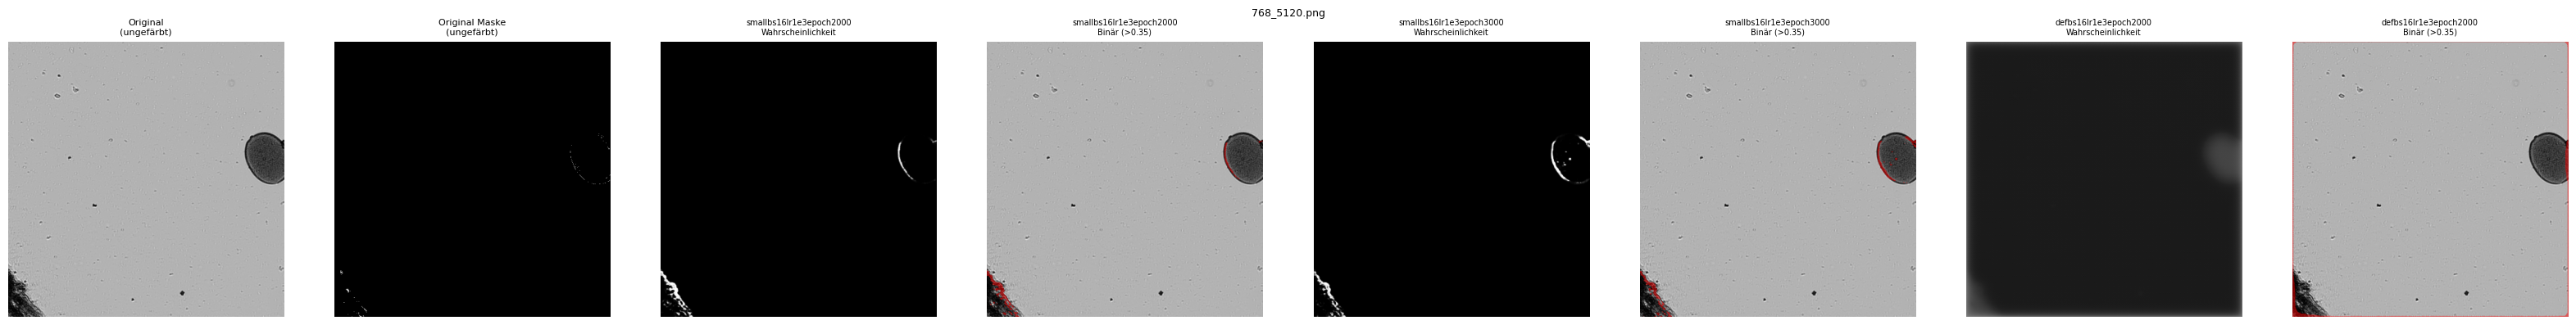

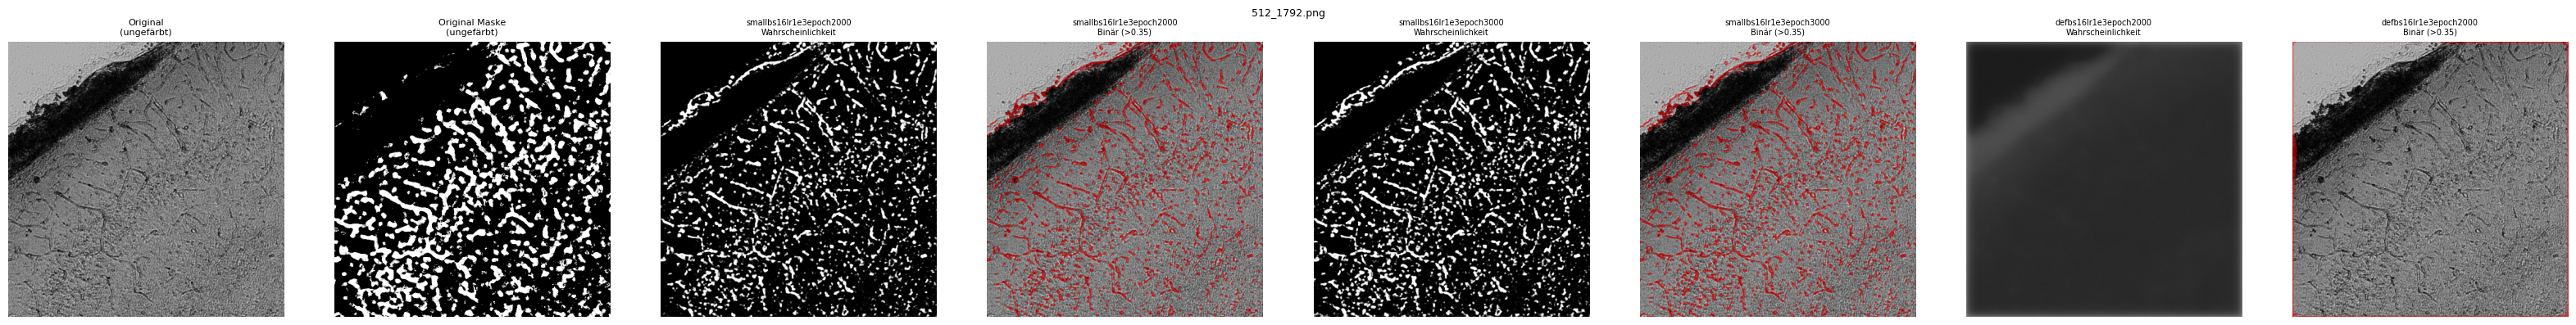

KeyboardInterrupt: 

In [13]:
# ── Visualisierung ────────────────────────────────────────────────
n_cols = 2 + len(models) * 2  # Bild + Soll-Mask + (prob + binary) pro Modell

for tile_path, mask_path in zip(tile_paths, mask_paths):
    tile = load_tile(tile_path)
    mask = load_tile(mask_path)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

    # Original
    axes[0].imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Original\n(ungefärbt)', fontsize=8)
    axes[0].axis('off')
    
    axes[1].imshow(mask.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Original Maske\n(ungefärbt)', fontsize=8)
    axes[1].axis('off')
    
    ungef_tiles
    
    # Vorhersagen
    for i, (run, model) in enumerate(models.items()):
        if tile.shape != (1, 512, 512):
            continue
        prob   = predict(model, tile)
        binary = (prob > threshold).astype(float)

        ax_prob   = axes[2 + i * 2]
        ax_binary = axes[3 + i * 2]

        ax_prob.imshow(prob, cmap='gray', vmin=0, vmax=1)
        ax_prob.set_title(f'{run}\nWahrscheinlichkeit', fontsize=7)
        ax_prob.axis('off')

        ax_binary.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
        overlay = np.zeros((*binary.shape, 4))
        overlay[..., 0] = 1.0
        overlay[..., 3] = binary * 0.5
        ax_binary.imshow(overlay)
        ax_binary.set_title(f'{run}\nBinär (>{threshold})', fontsize=7)
        ax_binary.axis('off')

    plt.suptitle(tile_path.name, fontsize=9)
    plt.tight_layout()
    plt.show()

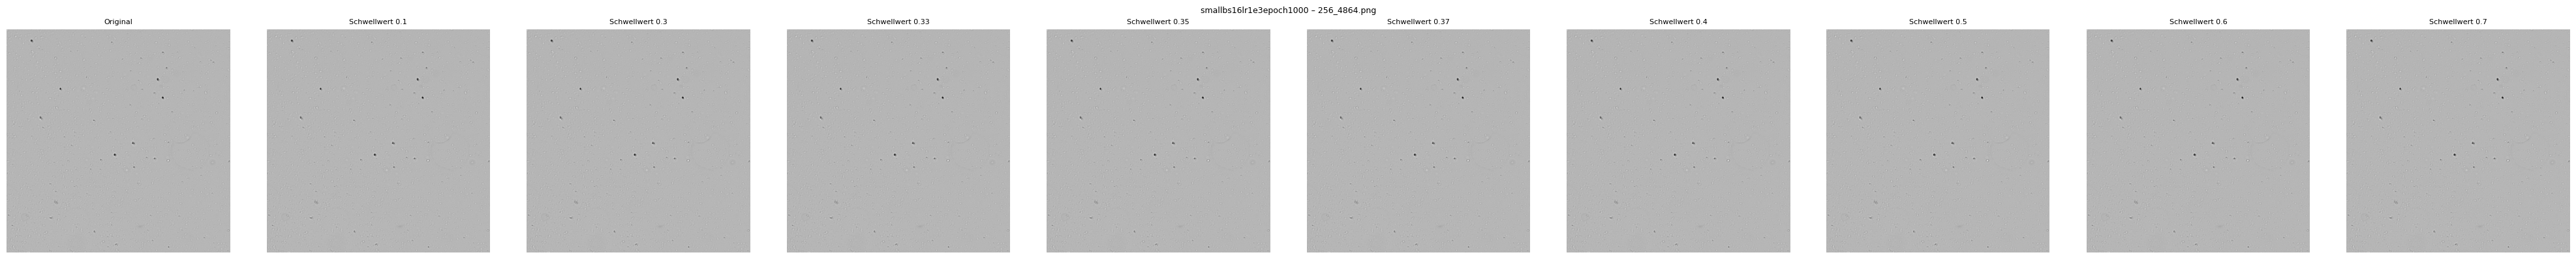

In [16]:
# ── Schwellwert interaktiv anpassen ──────────────────────────────
# Einzelnes Tile mit verschiedenen Schwellwerten anschauen
tile_idx   = 5   # welches Tile
run_name   = runs[1]  # welches Modell
thresholds = [0.1,0.3,0.33,0.35,0.37, 0.4, 0.5, 0.6, 0.7]

tile  = load_tile(tile_paths[tile_idx])
prob  = predict(models[run_name], tile)

fig, axes = plt.subplots(1, len(thresholds) + 1, figsize=(4*(len(thresholds)+1), 4))
axes[0].imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original', fontsize=8)
axes[0].axis('off')

for ax, t in zip(axes[1:], thresholds):
    binary = (prob > t).astype(float)
    ax.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    overlay = np.zeros((*binary.shape, 4))
    overlay[..., 0] = 1.0
    overlay[..., 3] = binary * 0.5
    ax.imshow(overlay)
    ax.set_title(f'Schwellwert {t}', fontsize=8)
    ax.axis('off')

plt.suptitle(f'{run_name} – {tile_paths[tile_idx].name}', fontsize=9)
plt.tight_layout()
plt.show()

# Tests

In [19]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

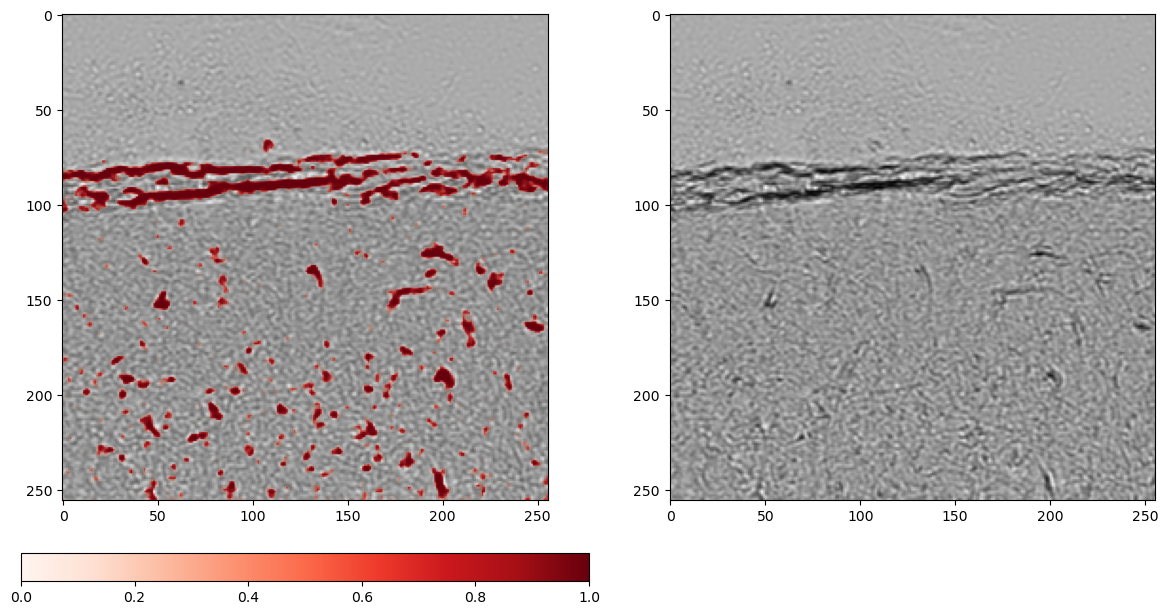

In [28]:
tile = load_tile("/home/tim/Dokumente/GitReps/Projektpraktikum_Master/augmentation_testing/dat/ungef/PE-2024-01126-M_00_s0021_PM_Complete_Transmittance_Stitched_Flat_v004_256_2816.png")

run_name   = runs[1]
model = models[run_name]
prob   = predict(model, tile)
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 6),
    constrained_layout=True
)
ax1.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
im = ax1.imshow(
    prob,
    cmap="Reds",      # oder "viridis", "turbo", "plasma", ...
    alpha=prob,       # Transparenz
    vmin=0,
    vmax=1,
)
# Colorbar hinzufügen
cbar = fig.colorbar(im, ax=ax1,  orientation="horizontal")
ax2.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
plt.show()

        

# Großes U-Net

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import os
from unet import Unet
import random

In [31]:
# ── Einstellungen ─────────────────────────────────────────────────
cwd        = Path.cwd().parent.parent
img_dir    = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/val/img'
ungef_dir    = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/ungef'
res_dir    = Path('res')

# Runs die verglichen werden sollen
runs = [
    #"MaskedGauss",
    #"LR4E10",
    #"LR3E100",
    #"smallbs64",
    #"smallbs16",
    #"smallbs16lr5e3",
    #"smallbs16lr5e3epoch1000",
    #"smallbs16lr1e3epoch1000",
    #"smallbs16lr1e3epoch2000",
    #"smallbs16lr1e3epoch3000",
    #"defbs16lr1e3epoch2000",
    "LR3E100",
    
]

n_tiles    = 6      # wie viele Tiles angezeigt werden
threshold  = 0.35    # Schwellwert für Binärmaske
device     = torch.device('cpu') # 'cuda' if torch.cuda.is_available() else 
print(f'Device: {device}')

# ── Modelle laden ─────────────────────────────────────────────────
models = {}
for run in runs:
    model_path = res_dir / run / 'last_model.pth'
    if not model_path.exists():
        print(f'⚠ {run}: last_model.pth nicht gefunden')
        continue
    state_dict = torch.load(model_path, map_location=device)

    state_dict = {
        k.replace("_orig_mod.", ""): v
        for k, v in state_dict.items()
    }
    m = Unet().to(device)
    m.load_state_dict(state_dict)
    m.eval()
    models[run] = m
    print(f'✓ {run} geladen')

print(f'\n{len(models)} Modelle geladen.')

Device: cpu
✓ LR3E100 geladen

1 Modelle geladen.


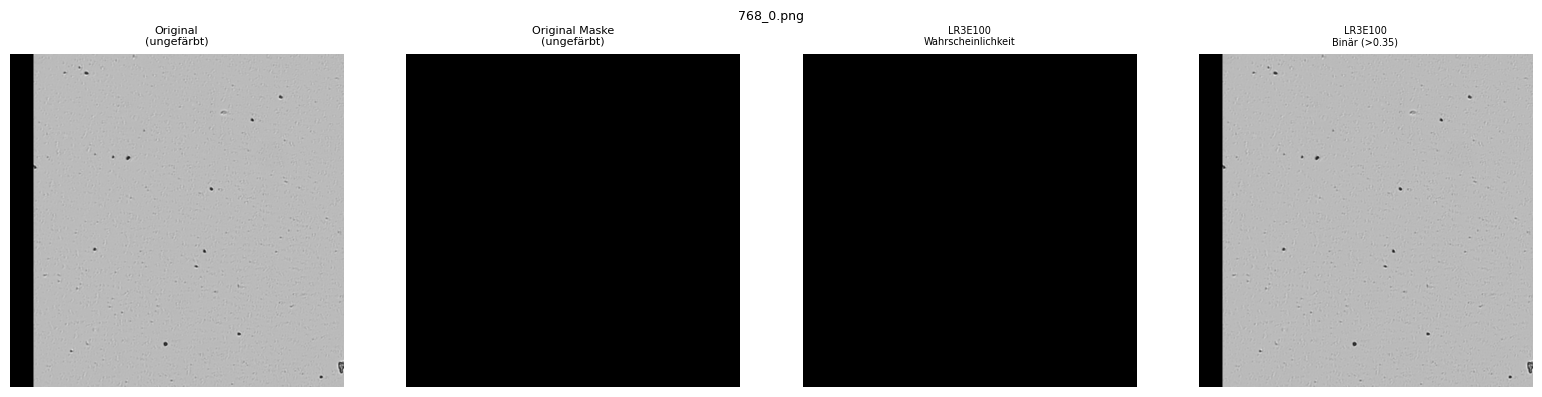

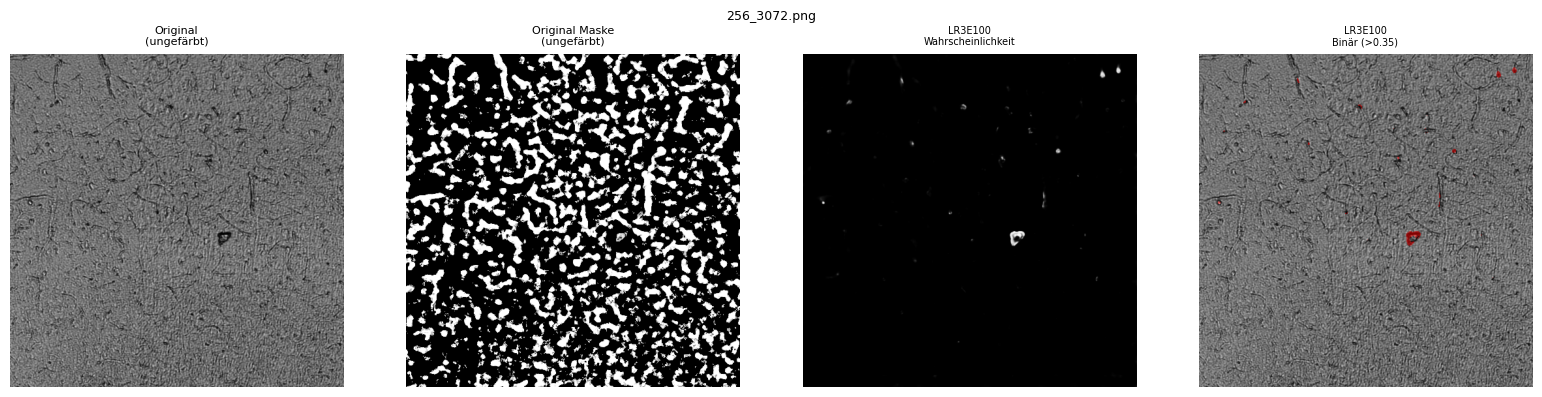

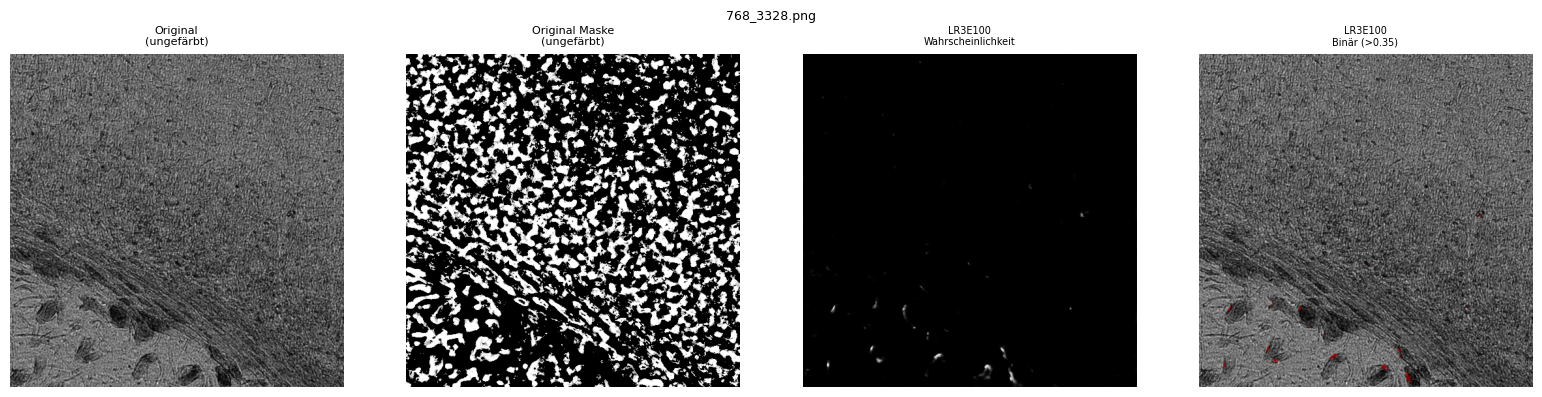

KeyboardInterrupt: 

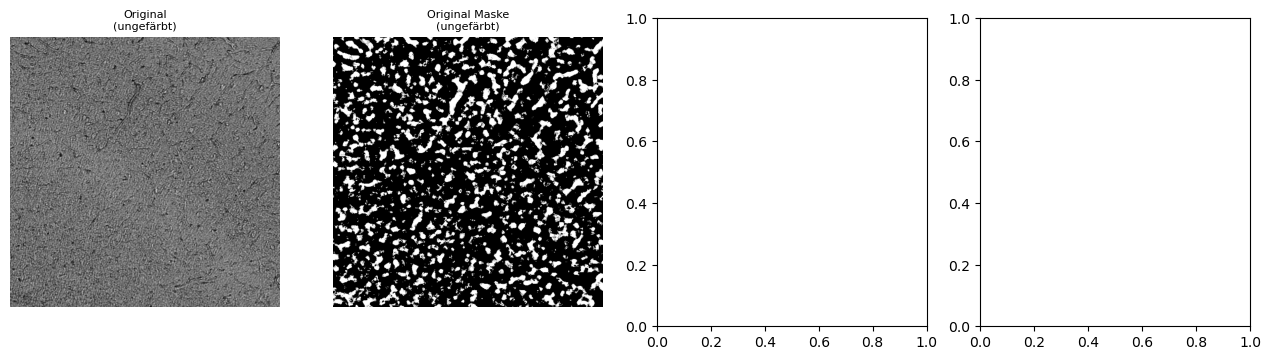

In [34]:
# ── Tiles laden ───────────────────────────────────────────────────
valid_ext = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')
# tile_paths = sorted([
#     p for p in img_dir.iterdir()
#     if p.suffix.lower() in valid_ext
# ])[:n_tiles]


all_tiles = sorted([
    p for p in img_dir.iterdir()
    if p.suffix.lower() in valid_ext
])

ungef_tiles = sorted([
    p for p in ungef_dir.iterdir()
    if p.suffix.lower() in valid_ext
])

tile_paths = random.sample(all_tiles, n_tiles)
mask_paths = [
    Path(str(p).replace("/img/", "/mask/"))
    for p in tile_paths
]
print(f'{len(tile_paths)} Tiles gefunden.')

def load_tile(path):
    img = Image.open(path).convert('L')
    t   = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.0
    return t

def predict(model, tile):
    with torch.no_grad():
        inp = tile.unsqueeze(0).to(device)
        out = model(inp)
        prob = torch.sigmoid(out).squeeze().numpy()
    return prob
# ── Visualisierung ────────────────────────────────────────────────
n_cols = 2 + len(models) * 2  # Bild + Soll-Mask + (prob + binary) pro Modell

for tile_path, mask_path in zip(tile_paths, mask_paths):
    tile = load_tile(tile_path)
    mask = load_tile(mask_path)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

    # Original
    axes[0].imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Original\n(ungefärbt)', fontsize=8)
    axes[0].axis('off')
    
    axes[1].imshow(mask.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Original Maske\n(ungefärbt)', fontsize=8)
    axes[1].axis('off')
    
    ungef_tiles
    
    # Vorhersagen
    for i, (run, model) in enumerate(models.items()):
        if tile.shape != (1, 512, 512):
            continue
        prob   = predict(model, tile)
        binary = (prob > threshold).astype(float)

        ax_prob   = axes[2 + i * 2]
        ax_binary = axes[3 + i * 2]

        ax_prob.imshow(prob, cmap='gray', vmin=0, vmax=1)
        ax_prob.set_title(f'{run}\nWahrscheinlichkeit', fontsize=7)
        ax_prob.axis('off')

        ax_binary.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
        overlay = np.zeros((*binary.shape, 4))
        overlay[..., 0] = 1.0
        overlay[..., 3] = binary * 0.5
        ax_binary.imshow(overlay)
        ax_binary.set_title(f'{run}\nBinär (>{threshold})', fontsize=7)
        ax_binary.axis('off')

    plt.suptitle(tile_path.name, fontsize=9)
    plt.tight_layout()
    plt.show()

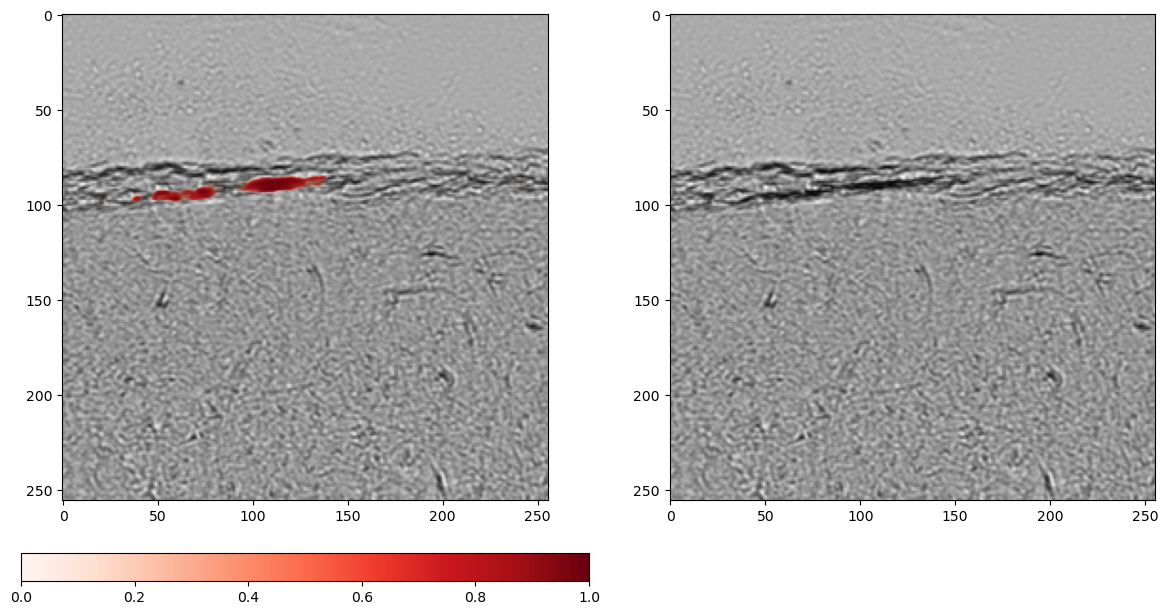

In [33]:
tile = load_tile("/home/tim/Dokumente/GitReps/Projektpraktikum_Master/augmentation_testing/dat/ungef/PE-2024-01126-M_00_s0021_PM_Complete_Transmittance_Stitched_Flat_v004_256_2816.png")

run_name   = runs[0]
model = models[run_name]
prob   = predict(model, tile)
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 6),
    constrained_layout=True
)
ax1.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
im = ax1.imshow(
    prob,
    cmap="Reds",      # oder "viridis", "turbo", "plasma", ...
    alpha=prob,       # Transparenz
    vmin=0,
    vmax=1,
)
# Colorbar hinzufügen
cbar = fig.colorbar(im, ax=ax1,  orientation="horizontal")
ax2.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
plt.show()

        